In [1]:
from CASP16_NA_assessment import *
import matplotlib.patches as patches

# global (capatalized variables) are defined in there
%matplotlib inline

In [2]:
group_score_hybrid = pd.read_csv('summary_tables/final_Z_NA_hybrid.csv').rename(columns={'Z_0.3_0.7_NA':'Sum(Z>0)'})
group_score_hybrid['Score'] = 'Z-hybrid'
group_score_multimer = pd.read_csv('summary_tables/final_Z_NA_multimer.csv').rename(columns={'Z_0.3_0.7':'Sum(Z>0)'})
group_score_multimer['Score'] = 'Z-RNA-multimer'
group_score_ligand = pd.read_csv('summary_tables/final_Z_NA_ligand.csv').rename(columns={'Z_0.5_0.5':'Sum(Z>0)'})
group_score_ligand['Score'] = 'Z-ligand'
group_score_monomer = pd.read_csv('summary_tables/final_Z_NA_monomer.csv').rename(columns={'Z_CASP16_t30_g30_l40':'Sum(Z>0)'})
group_score_monomer['Score'] = 'Z-NA-monomer'

all_scores = pd.concat([group_score_hybrid,group_score_multimer,group_score_ligand,group_score_monomer])
all_scores

,gr_code,Sum(Z>0),lower_bound,upper_bound,Score
0,KiharaLab - 294,8.676110,1.319252,2.936155,Z-hybrid
1,CSSB_experimental - 286,7.833106,2.332530,3.054642,Z-hybrid
2,Vfold - 481,7.622783,2.628202,2.275212,Z-hybrid
3,Zheng - 462,7.371475,2.170042,2.337201,Z-hybrid
4,MIEnsembles-Server - S 110,6.794840,1.193435,2.158173,Z-hybrid
...,...,...,...,...,...
34,kiharalab_server - S 267,0.973922,0.704275,0.609051,Z-NA-monomer
35,SoutheRNA - 156,0.000000,0.000000,0.000000,Z-NA-monomer
36,GeneSilicoRNA-server - S 306,0.000000,0.000000,0.000000,Z-NA-monomer
37,SimRNA-server - S 094,0.000000,0.000000,0.000000,Z-NA-monomer


C:\Users\racha\AppData\Local\Temp\ipykernel_1432\1293937873.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  order = all_scores.groupby('gr_code')['Sum(Z>0)'].sum().sort_values(ascending=False).index
C:\Users\racha\AppData\Local\Temp\ipykernel_1432\1293937873.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  lowerbound = all_scores.groupby('gr_code').lower_bound.sum()
C:\Users\racha\AppData\Local\Temp\ipykernel_1432\1293937873.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observ

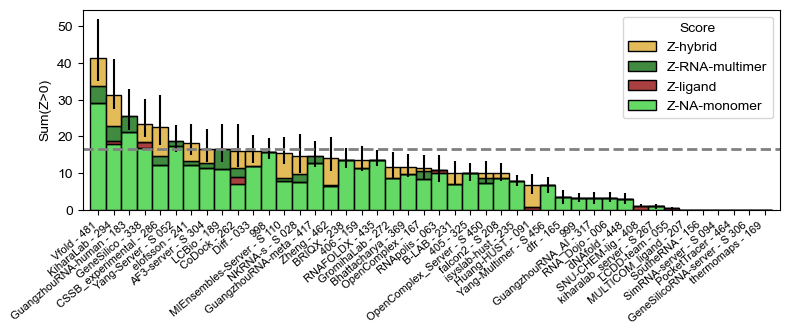

In [9]:
plt.figure(figsize=(9,2.6))
order = all_scores.groupby('gr_code')['Sum(Z>0)'].sum().sort_values(ascending=False).index
all_scores['gr_code'] =pd.Categorical(all_scores['gr_code'] , order,)
g=sns.histplot(all_scores, x='gr_code', hue='Score', weights='Sum(Z>0)', multiple='stack',
              palette={'Z-ligand':'darkred','Z-RNA-multimer':'darkgreen','Z-NA-monomer':'limegreen','Z-hybrid':'goldenrod'})
x_labels = [label.get_text() for label in g.get_xticklabels()]
lowerbound = all_scores.groupby('gr_code').lower_bound.sum()
upperbound = all_scores.groupby('gr_code').upper_bound.sum()
score = all_scores.groupby('gr_code')['Sum(Z>0)'].sum()




for i, patch in enumerate(g.patches[:len(score)]):
    x = patch.get_x() + patch.get_width() / 2  # x-coordinate of the bar's center
    y = score.loc[x_labels[i]]  # The *height* of the bar is its y-value at the top.  This is where the errorbar should be added
    err = [[lowerbound.loc[x_labels[i]]], [upperbound.loc[x_labels[i]]]]
    g.errorbar(x, y, yerr=err, fmt='none', color='black', capsize=0)  # Add error bars


y_coord = score['AF3-server - S 304'] 
g.hlines(y_coord,-1,len(order), color='grey', linestyle='--', 
            linewidth=2, label='AF3-server - 304')

t=g.set_xticklabels(labels=g.get_xticklabels(),ha="right",rotation = 40,size=8)
g.set_ylabel('Sum(Z>0)')
g.set_xlabel('')
g.set_xlim(-1,len(order))



plt.savefig('figure_subpanels/overall_scores.png',dpi=400, bbox_inches='tight')
plt.savefig('figure_subpanels/overall_scores.svg',dpi=400, bbox_inches='tight')
plt.show()

## Figure 8

In [10]:
template_info = TEMPLATE_INFO.copy()

In [11]:
template_info['tm-align_ratio'] = template_info['Best Prediction TM align'] / template_info['Best Template TM align']
template_info['tm-align_diff'] = template_info['Best Prediction TM align'] - template_info['Best Template TM align']

template_info.head()

,Competition Deadline,Competition,Target,Target Description,Best Prediction,Best Prediction TM align,Best Template,Best Template Description,Best Template TM align,tm-align_ratio,tm-align_diff
0,01-Dec-2010,RNA-Puzzles,PZ1,human thymidylate synthase element,PZ1_Bujnicki_5,0.39469,3GM7,1.58 A resolution X-ray structure of (CUG)6,0.53890,0.732399,-0.14421
1,01-Dec-2010,RNA-Puzzles,PZ3,glycine riboswitch,PZ3_Das_5,0.35605,2D3O,Structure of Ribosome Binding Domain of the Tr...,0.38699,0.920050,-0.03094
2,18-Dec-2011,RNA-Puzzles,PZ4,SAM-I riboswitch aptamer,PZ4_Chen_2,0.43474,3GX3,Crystal structure of the T. tengcongensis SAM-...,0.34522,1.259313,0.08952
3,05-Oct-2012,RNA-Puzzles,PZ5,GIR ribozyme,PZ5_Das_2,0.49918,3BBX,The Hsp15 protein fitted into the low resoluti...,0.33780,1.477738,0.16138
4,10-Oct-2012,RNA-Puzzles,PZ6,adenosylcobalamin riboswitch,PZ6_Das_1,0.44893,2QBZ,Structure of the M-Box Riboswitch Aptamer Domain,0.32040,1.401155,0.12853


In [12]:
template_info[(template_info['Best Prediction TM align']>0.8) & (template_info['Best Template TM align']<0.8) ]

,Competition Deadline,Competition,Target,Target Description,Best Prediction,Best Prediction TM align,Best Template,Best Template Description,Best Template TM align,tm-align_ratio,tm-align_diff
43,24-Jun-2022,CASP15,R1138,6HBC-Young,R1138TS232_4,0.80048,1VQ9,The structure of CCA-PHE-CAP-BIO and the antib...,0.32721,2.446380,0.47327
56,04-Jun-2024,CASP16,R1221s2,RNase P enzyme-substrate complex,R1221s2TS481_1,0.83429,2A64,Crystal Structure of Bacterial Ribonuclease P RNA,0.61289,1.361239,0.22140
58,06-Jun-2024,CASP16,R1224s2,RNase P enzyme-substrate complex,R1224s2TS417_3,0.87127,2A64,Crystal Structure of Bacterial Ribonuclease P RNA,0.64787,1.344822,0.22340
76,01-Aug-2024,CASP16,R1289,Precursor tRNA,R1289TS294_1,0.83547,1U6B,CRYSTAL STRUCTURE OF A SELF-SPLICING GROUP I I...,0.63081,1.324440,0.20466


In [13]:
markers = {'RNA-Puzzles': 'X', 'CASP15': 'o', 'CASP16': 's'}
colors = {'RNA-Puzzles': 'orange', 'CASP15': '#ADD8E6', 'CASP16': '#191970'}

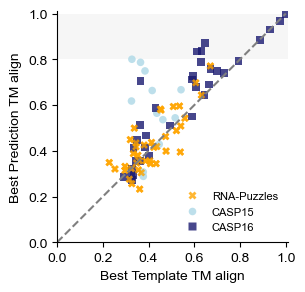

In [14]:
plt.figure(figsize=(3,3))
plt.gca().add_patch(patches.Rectangle(
        (0, 0.8),  7, 0.2,  
        facecolor='lightgrey',
        edgecolor='none',alpha=0.2))


markers = {'RNA-Puzzles': 'X', 'CASP15': 'o', 'CASP16': 's'}
colors = {'RNA-Puzzles': 'orange', 'CASP15': '#ADD8E6', 'CASP16': '#191970'} #Light blue and Dark blue hex codes

sns.scatterplot(template_info,y='Best Prediction TM align',x='Best Template TM align',
               hue='Competition',style='Competition',
               markers=markers, palette=colors, s=30,alpha=0.8,
               edgecolor='none')


# Plot RNA-Puzzles on top
sns.scatterplot(data=template_info[template_info['Competition'] == 'RNA-Puzzles'],
                y='Best Prediction TM align', x='Best Template TM align',
                marker='X', color='orange', s=30, alpha=0.8,
               edgecolor='none')
plt.xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlim(0, 1.01)
plt.ylim(0, 1.01)
sns.despine(right=True, top=True)
plt.gca().set_aspect('equal', adjustable='box')
handles, labels = plt.gca().get_legend_handles_labels()
legend = plt.legend(handles, labels, loc='lower right', frameon=False, fontsize=8) 

plt.savefig(f"figure_subpanels/historical_tm_align.png",dpi=400, bbox_inches='tight', transparent=True)
plt.savefig(f"figure_subpanels/historical_tm_align.svg",dpi=400, bbox_inches='tight', transparent=True)
plt.show()

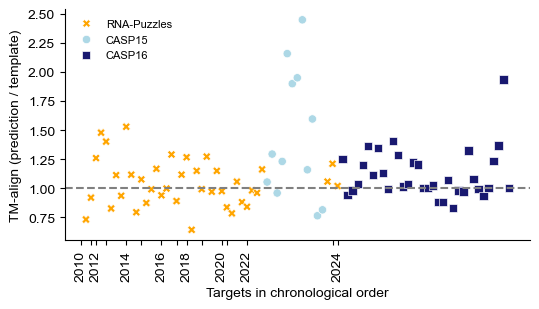

In [15]:
plt.figure(figsize=(6,3))

template_info['timestamp'] = pd.to_datetime(template_info['Competition Deadline']) 
template_info = template_info.sort_values(by='timestamp')
template_info['index'] = range(len(template_info))
g = sns.scatterplot(data=template_info,x='index',y='tm-align_ratio',
               hue='Competition',style='Competition',
               markers=markers, palette=colors)
x0,x1 = g.get_xlim()
plt.hlines(1,x0,x1,linestyle='--', color='gray')
plt.xlim(x0,x1)
years = template_info['timestamp'].dt.year.unique()
year_indices = template_info.groupby(template_info['timestamp'].dt.year)['index'].first().values


# Set custom x-axis ticks and labels
t=plt.xticks([x-1 for x in year_indices], [x if int(x)%2==0 else '' for x in years],
          rotation=90,ha='center')

handles, labels = plt.gca().get_legend_handles_labels()
legend = plt.legend(handles, labels, loc='upper left', frameon=False, fontsize=8) 
sns.despine(right=True, top=True)

plt.xlabel('Targets in chronological order')
plt.ylabel('TM-align (prediction / template)')

plt.savefig(f"figure_subpanels/historical_tm_align_timeline.png",dpi=400, bbox_inches='tight', transparent=True)
plt.savefig(f"figure_subpanels/historical_tm_align_timeline.svg",dpi=400, bbox_inches='tight', transparent=True)
plt.show()

(np.float64(-4.2), np.float64(88.2))


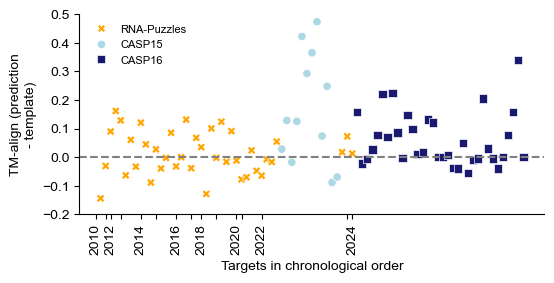

In [16]:
plt.figure(figsize=(6,2.6))

template_info['timestamp'] = pd.to_datetime(template_info['Competition Deadline']) 
template_info = template_info.sort_values(by='timestamp')
template_info['index'] = range(len(template_info))
g = sns.scatterplot(data=template_info,x='index',y='tm-align_diff',
               hue='Competition',style='Competition',
               markers=markers, palette=colors)
x0,x1 = g.get_xlim()
plt.hlines(0,x0,x1,linestyle='--', color='gray')
plt.xlim(x0,x1)
years = template_info['timestamp'].dt.year.unique()
year_indices = template_info.groupby(template_info['timestamp'].dt.year)['index'].first().values


# Set custom x-axis ticks and labels
t=plt.xticks([x-1 for x in year_indices], [x if int(x)%2==0 else '' for x in years],
          rotation=90,ha='center')

handles, labels = plt.gca().get_legend_handles_labels()
legend = plt.legend(handles, labels, loc='upper left', frameon=False, fontsize=8) 
sns.despine(right=True, top=True)

plt.ylim(-0.2,0.5)
plt.xlabel('Targets in chronological order')
plt.ylabel('TM-align (prediction\n- template)')
print(plt.gca().get_xlim())
plt.savefig(f"figure_subpanels/historical_tm_align_diff_timeline.png",dpi=400, bbox_inches='tight', transparent=True)
plt.savefig(f"figure_subpanels/historical_tm_align_diff_timeline.svg",dpi=400, bbox_inches='tight', transparent=True)
plt.show()

In [18]:
casp15 = pd.read_csv('../raw_scores/casp15_rna_all_score_per_group_withZ_230403.csv')
casp15_server = [229,125,35,489,131]
casp15.groupby('target').tm_score.max()
casp15_best_server = casp15[casp15.gr_code.isin(casp15_server)].groupby('target').tm_score.max()


In [21]:
casp16_server = GROUP_SERVER[GROUP_SERVER.Server=='Server'].index.to_list()
casp16 = pd.read_csv('summary_tables/NA_monomer_scores.csv')
casp16_server = [i.rsplit('-',1)[0] + '- S' + i.rsplit('-',1)[1] for i in casp16_server]
casp16_best_server = casp16[casp16.gr_code.isin(casp16_server)].groupby('target').TM_align.max()
rna_puzzle = pd.read_csv('../raw_scores/all_rnapz_model_eval.csv')
rna_puzzle = rna_puzzle[~rna_puzzle.PDB.str.contains('solution')]
rna_puzzle['group'] = rna_puzzle.PDB.apply(lambda x: x.rsplit('_',1)[0].split('_',1)[1])
possible_groups = pd.read_csv('../raw_scores/rnapuzzles_human_webserver_stastic.csv')
possible_groups = possible_groups[possible_groups.Methods=='Server'].group.to_list()
possible_groups.extend(['SimRNAweb', 'RNAComposer2', 'LeeServer', 'LeeASmodel'])
possible_groups = [p.lower() for p in possible_groups]
rna_puzzle = rna_puzzle[rna_puzzle.group.str.lower().isin(possible_groups)]
rna_puzzle_best_server = rna_puzzle.groupby('eval_structure').TMscore.max()

template_info['server_best'] = template_info.Target.map(pd.concat([rna_puzzle_best_server,casp15_best_server,casp16_best_server]).to_dict())
template_info['server_best_tm-align_ratio'] = template_info['server_best'] / template_info['Best Template TM align']
template_info['server_best_tm-align_diff'] = template_info['server_best'] - template_info['Best Template TM align']
template_info['server_human_tm-align_diff'] = template_info['server_best'] - template_info['Best Prediction TM align']
template_info

,Competition Deadline,Competition,Target,Target Description,Best Prediction,Best Prediction TM align,Best Template,Best Template Description,Best Template TM align,tm-align_ratio,tm-align_diff,timestamp,index,server_best,server_best_tm-align_ratio,server_best_tm-align_diff,server_human_tm-align_diff
0,01-Dec-2010,RNA-Puzzles,PZ1,human thymidylate synthase element,PZ1_Bujnicki_5,0.39469,3GM7,1.58 A resolution X-ray structure of (CUG)6,0.53890,0.732399,-0.14421,2010-12-01,0,NaN,NaN,NaN,NaN
1,01-Dec-2010,RNA-Puzzles,PZ3,glycine riboswitch,PZ3_Das_5,0.35605,2D3O,Structure of Ribosome Binding Domain of the Tr...,0.38699,0.920050,-0.03094,2010-12-01,1,NaN,NaN,NaN,NaN
2,18-Dec-2011,RNA-Puzzles,PZ4,SAM-I riboswitch aptamer,PZ4_Chen_2,0.43474,3GX3,Crystal structure of the T. tengcongensis SAM-...,0.34522,1.259313,0.08952,2011-12-18,2,NaN,NaN,NaN,NaN
3,05-Oct-2012,RNA-Puzzles,PZ5,GIR ribozyme,PZ5_Das_2,0.49918,3BBX,The Hsp15 protein fitted into the low resoluti...,0.33780,1.477738,0.16138,2012-10-05,3,NaN,NaN,NaN,NaN
4,10-Oct-2012,RNA-Puzzles,PZ6,adenosylcobalamin riboswitch,PZ6_Das_1,0.44893,2QBZ,Structure of the M-Box Riboswitch Aptamer Domain,0.32040,1.401155,0.12853,2012-10-10,4,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80,07-Aug-2024,CASP16,R1281,2F RNA 6-helix bundle dimer,R1281TS189_1,0.64538,7PTK,Young conformer of a 6-helix bundle of RNA wit...,0.64405,1.002065,0.00133,2024-08-07,80,0.641,0.995264,-0.00305,-0.00438
81,12-Aug-2024,CASP16,R1283v1,Enterococcus ncRNA,R1283v1TS304_5,0.41236,7RQB,Crystal structure of the Thermus thermophilus ...,0.33413,1.234130,0.07823,2024-08-12,81,0.412,1.233053,0.07787,-0.00036
82,12-Aug-2024,CASP16,R1296,G34U mutant of M1209 complex,R1296TS481_3,0.58751,8P2F,Staphylococcus aureus 70S ribosome with elonga...,0.42965,1.367415,0.15786,2024-08-12,82,0.432,1.005470,0.00235,-0.15551
83,13-Aug-2024,CASP16,R1285,OLE,R1285TS235_4,0.70522,7ZW0,FAP-80S Complex - Rotated state,0.36471,1.933646,0.34051,2024-08-13,83,0.677,1.856269,0.31229,-0.02822


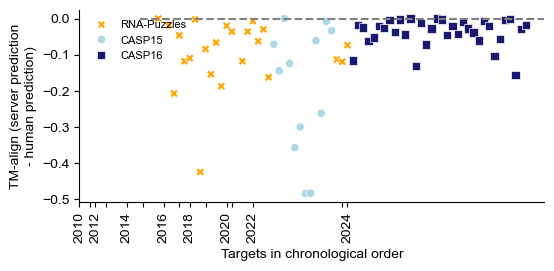

In [26]:
plt.figure(figsize=(6,2.5))

template_info['timestamp'] = pd.to_datetime(template_info['Competition Deadline']) 
template_info = template_info.sort_values(by='timestamp')
template_info['index'] = range(len(template_info))
g = sns.scatterplot(data=template_info,x='index',y='server_human_tm-align_diff',
               hue='Competition',style='Competition',
               markers=markers, palette=colors)
x0,x1 = g.get_xlim()
plt.hlines(0,x0,x1,linestyle='--', color='gray')
plt.xlim(x0,x1)
years = template_info['timestamp'].dt.year.unique()
year_indices = template_info.groupby(template_info['timestamp'].dt.year)['index'].first().values


# Set custom x-axis ticks and labels
t=plt.xticks([x-1 for x in year_indices], [x if int(x)%2==0 else '' for x in years],
          rotation=90,ha='center')

handles, labels = plt.gca().get_legend_handles_labels()
legend = plt.legend(handles, labels, loc='upper left', frameon=False, fontsize=8) 
sns.despine(right=True, top=True)

plt.xlabel('Targets in chronological order')
plt.ylabel('TM-align (server prediction\n- human prediction)')
plt.savefig(f"figure_subpanels/historical_tm_align_server_diff_timeline.png",dpi=400, bbox_inches='tight', transparent=True)
plt.savefig(f"figure_subpanels/historical_tm_align_server_diff_timeline.svg",dpi=400, bbox_inches='tight', transparent=True)
plt.show()

(np.float64(-1.0), np.float64(87.5))


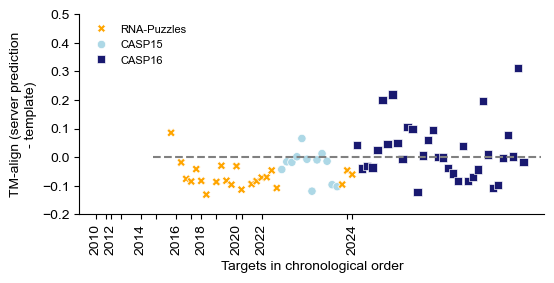

In [27]:
plt.figure(figsize=(6,2.6))

template_info['timestamp'] = pd.to_datetime(template_info['Competition Deadline']) 
template_info = template_info.sort_values(by='timestamp')
template_info['index'] = range(len(template_info))
g = sns.scatterplot(data=template_info,x='index',y='server_best_tm-align_diff',
               hue='Competition',style='Competition',
               markers=markers, palette=colors)
x0,x1 = g.get_xlim()
plt.hlines(0,x0,x1,linestyle='--', color='gray')
plt.xlim(x0,x1)
years = template_info['timestamp'].dt.year.unique()
year_indices = template_info.groupby(template_info['timestamp'].dt.year)['index'].first().values


# Set custom x-axis ticks and labels
t=plt.xticks([x-1 for x in year_indices], [x if int(x)%2==0 else '' for x in years],
          rotation=90,ha='center')

handles, labels = plt.gca().get_legend_handles_labels()
legend = plt.legend(handles, labels, loc='upper left', frameon=False, fontsize=8) 
sns.despine(right=True, top=True)
plt.ylim(-0.2,0.5)
print(plt.gca().get_xlim())
plt.xlim(-4.2, 88.2)

plt.xlabel('Targets in chronological order')
plt.ylabel('TM-align (server prediction\n- template)')

plt.savefig(f"figure_subpanels/historical_tm_align_server_diff_timeline.png",dpi=400, bbox_inches='tight', transparent=True)
plt.savefig(f"figure_subpanels/historical_tm_align_server_diff_timeline.svg",dpi=400, bbox_inches='tight', transparent=True)
plt.show()

In [28]:
rna_puzzle = pd.read_csv('../raw_scores/all_rnapz_model_eval.csv')
rna_puzzle = rna_puzzle[~rna_puzzle.PDB.str.contains('solution')]
rna_puzzle['group'] = rna_puzzle.PDB.apply(lambda x: x.rsplit('_',1)[0].split('_',1)[1])
possible_groups = pd.read_csv('../raw_scores/rnapuzzles_human_webserver_stastic.csv')
possible_groups = possible_groups[possible_groups.Methods=='Server'].group.to_list()
possible_groups.extend(['SimRNAweb', 'RNAComposer2', 'LeeServer', 'LeeASmodel'])
possible_groups = [p.lower() for p in possible_groups]
rna_puzzle = rna_puzzle[rna_puzzle.group.str.lower().isin(possible_groups)]
rna_puzzle.groupby('eval_structure').TMscore.max().to_dict()

{'PZ15': 0.59364,
 'PZ15noend': 0.59363,
 'PZ16a': 0.50856,
 'PZ16b': 0.42716,
 'PZ17': 0.32914,
 'PZ18': 0.37535,
 'PZ19': 0.27017,
 'PZ20': 0.21122,
 'PZ21': 0.21403,
 'PZ22': 0.2301,
 'PZ22Dimer': 0.27835,
 'PZ23': 0.27248,
 'PZ24': 0.42429,
 'PZ25': 0.34686,
 'PZ26': 0.47639,
 'PZ26tBox': 0.47639,
 'PZ26tRNA': 0.47639,
 'PZ27': 0.51014,
 'PZ27tBox': 0.51014,
 'PZ27tRNA': 0.51014,
 'PZ28': 0.44281,
 'PZ28tBox': 0.44281,
 'PZ28tRNA': 0.44281,
 'PZ29': 0.36285,
 'PZ31': 0.31879,
 'PZ32': 0.32125,
 'PZ33': 0.33695,
 'PZ34': 0.35295,
 'PZ35': 0.38961,
 'PZ36': 0.22566,
 'PZ37': 0.20092,
 'PZ38': 0.29821,
 'PZ39': 0.57022}

In [29]:
possible_groups = pd.read_csv('../raw_scores/rnapuzzles_human_webserver_stastic.csv').group.to_list()
possible_groups = [p.lower() for p in possible_groups]
# 

In [31]:
possible_groups

['3drna',
 '3drnaas2',
 'ares',
 'aresapo',
 'aresgua',
 'adamiak',
 'boniecki',
 'bujnicki',
 'chen',
 'das',
 'dasaresapo',
 'dasaresapo',
 'daseminfo',
 'dasfarfar2aresholo',
 'dasfarfar2apo',
 'dasfarfar2holo',
 'dasfarfar2nnapo',
 'dasfarfar2nnholo',
 'dasfarfar2apo',
 'dasoriginal',
 'daspostdeadline',
 'dasswm',
 'dasswmapo',
 'dastfn',
 'dfold',
 'dfold2',
 'dimaio',
 'ding',
 'dokholyan',
 'farfar2',
 'farfar2apo',
 'farfar2gua',
 'genesilico1',
 'genesilico2',
 'genesilico3',
 'genesilico4',
 'kollmann',
 'lee',
 'leeas',
 'nithin',
 'perez',
 'rnacomposer',
 'rnacomposeras1',
 'rnacomposeras2',
 'rw3d',
 'rw3das1',
 'rw3das2',
 'swmapo',
 'sanbonmatsu',
 'simrna',
 'simrnaas1',
 'simrnaas2',
 'southerna',
 'szachniuk',
 'tfn',
 'vfold3d',
 'vfoldla',
 'xiao',
 'xiong',
 'yagoubali',
 'yangserver',
 'yang',
 'zhou',
 'ifoldrna']

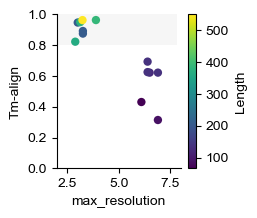

In [35]:
plt.figure(figsize=(2,2))
plt.gca().add_patch(patches.Rectangle(
        (0.8, 0.8),  7, 0.2,  
        facecolor='lightgrey',
        edgecolor='none',alpha=0.2))

stuct_compare = pd.read_csv('../raw_scores/IndepdentStructureComparisons.csv')
stuct_compare['min_resolution' ] = stuct_compare[['Resolution1','Resolution2']].min(axis=1)
stuct_compare['max_resolution' ] = stuct_compare[['Resolution1','Resolution2']].max(axis=1)
stuct_compare
g=sns.scatterplot(stuct_compare, y='Tm-align',x='max_resolution',marker='o',hue='Length',palette='viridis',legend=False,
               linewidth=0)
plt.ylim(0,1)
plt.xlim(2,8)
sns.despine(right=True, top=True)
sm = plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(vmin=stuct_compare['Length'].min(), vmax=stuct_compare['Length'].max()))
plt.colorbar(sm,label="Length",ax=g)

plt.savefig(f"figure_subpanels/indepdent_structure.png",dpi=400, bbox_inches='tight', transparent=True)
plt.savefig(f"figure_subpanels/indepdent_structure.svg",dpi=400, bbox_inches='tight', transparent=True)
plt.show()

## same plots fig 8 just mark synthetic

In [36]:
synthetics = ['R1126','R1128','R1136','R1138']
template_info.loc[template_info.Target.isin(synthetics),'Competition'] = 'synthetic'
template_info['timestamp_numeric'] = template_info['timestamp'].astype(int) // 10**9 

In [37]:
template_info.Competition.unique()

array(['RNA-Puzzles', 'CASP15', 'synthetic', 'CASP16'], dtype=object)

In [38]:
markers = {'RNA-Puzzles': 'X', 'CASP15': 'o', 'CASP16': 's','synthetic':'*'}
colors = {'RNA-Puzzles': 'orange', 'CASP15': '#ADD8E6', 'CASP16': '#191970','synthetic':'#7997a1'}

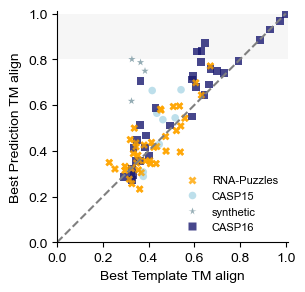

In [39]:
plt.figure(figsize=(3,3))
plt.gca().add_patch(patches.Rectangle(
        (0, 0.8),  7, 0.2,  
        facecolor='lightgrey',
        edgecolor='none',alpha=0.2))

sns.scatterplot(template_info,y='Best Prediction TM align',x='Best Template TM align',
               hue='Competition',style='Competition',
               markers=markers, palette=colors, s=30,alpha=0.8,
               edgecolor='none')


# Plot RNA-Puzzles on top
sns.scatterplot(data=template_info[template_info['Competition'] == 'RNA-Puzzles'],
                y='Best Prediction TM align', x='Best Template TM align',
                marker='X', color='orange', s=30, alpha=0.8,
               edgecolor='none')
plt.xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlim(0, 1.01)
plt.ylim(0, 1.01)
sns.despine(right=True, top=True)
plt.gca().set_aspect('equal', adjustable='box')
handles, labels = plt.gca().get_legend_handles_labels()
legend = plt.legend(handles, labels, loc='lower right', frameon=False, fontsize=8) 

plt.savefig(f"figure_subpanels/historical_tm_align.png",dpi=400, bbox_inches='tight', transparent=True)
plt.savefig(f"figure_subpanels/historical_tm_align.svg",dpi=400, bbox_inches='tight', transparent=True)
plt.show()

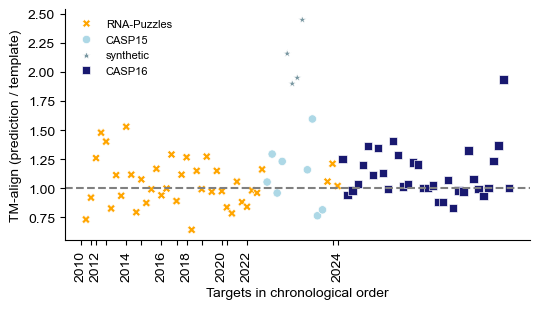

In [40]:
plt.figure(figsize=(6,3))

template_info['timestamp'] = pd.to_datetime(template_info['Competition Deadline']) 
template_info = template_info.sort_values(by='timestamp')
template_info['index'] = range(len(template_info))
g = sns.scatterplot(data=template_info,x='index',y='tm-align_ratio',
               hue='Competition',style='Competition',
               markers=markers, palette=colors)
x0,x1 = g.get_xlim()
plt.hlines(1,x0,x1,linestyle='--', color='gray')
plt.xlim(x0,x1)
years = template_info['timestamp'].dt.year.unique()
year_indices = template_info.groupby(template_info['timestamp'].dt.year)['index'].first().values


# Set custom x-axis ticks and labels
t=plt.xticks([x-1 for x in year_indices], [x if int(x)%2==0 else '' for x in years],
          rotation=90,ha='center')

handles, labels = plt.gca().get_legend_handles_labels()
legend = plt.legend(handles, labels, loc='upper left', frameon=False, fontsize=8) 
sns.despine(right=True, top=True)

plt.xlabel('Targets in chronological order')
plt.ylabel('TM-align (prediction / template)')

plt.savefig(f"figure_subpanels/historical_tm_align_timeline.png",dpi=400, bbox_inches='tight', transparent=True)
plt.savefig(f"figure_subpanels/historical_tm_align_timeline.svg",dpi=400, bbox_inches='tight', transparent=True)
plt.show()

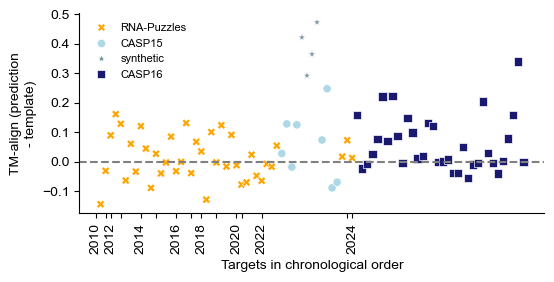

In [41]:
plt.figure(figsize=(6,2.6))

template_info['timestamp'] = pd.to_datetime(template_info['Competition Deadline']) 
template_info = template_info.sort_values(by='timestamp')
template_info['index'] = range(len(template_info))
g = sns.scatterplot(data=template_info,x='index',y='tm-align_diff',
               hue='Competition',style='Competition',
               markers=markers, palette=colors)
x0,x1 = g.get_xlim()
plt.hlines(0,x0,x1,linestyle='--', color='gray')
plt.xlim(x0,x1)
years = template_info['timestamp'].dt.year.unique()
year_indices = template_info.groupby(template_info['timestamp'].dt.year)['index'].first().values


# Set custom x-axis ticks and labels
t=plt.xticks([x-1 for x in year_indices], [x if int(x)%2==0 else '' for x in years],
          rotation=90,ha='center')

handles, labels = plt.gca().get_legend_handles_labels()
legend = plt.legend(handles, labels, loc='upper left', frameon=False, fontsize=8) 
sns.despine(right=True, top=True)

plt.xlabel('Targets in chronological order')
plt.ylabel('TM-align (prediction\n- template)')

plt.savefig(f"figure_subpanels/historical_tm_align_diff_timeline.png",dpi=400, bbox_inches='tight', transparent=True)
plt.savefig(f"figure_subpanels/historical_tm_align_diff_timeline.svg",dpi=400, bbox_inches='tight', transparent=True)
plt.show()

In [42]:
casp15 = pd.read_csv('../raw_scores/casp15_rna_all_score_per_group_withZ_230403.csv')
casp15_server = [229,125,35,489,131]
casp15.groupby('target').tm_score.max()
casp15_best_server = casp15[casp15.gr_code.isin(casp15_server)].groupby('target').tm_score.max()


In [43]:
casp15

,target,gr_code,clashscore,global_rmsd,cc_mask,cc_peaks,tempy_mi,tempy_smoc,ai,gdt_ts,...,Z_inf_all,Z_cc_mask,Z_cc_peaks,Z_tempy_mi,Z_tempy_smoc,Z_ai,Z_rna,Z_em,Z_topo,Z_local
0,R1107,29,0.00,17.10,NaN,NaN,NaN,NaN,NaN,35.145,...,-0.386145,NaN,NaN,NaN,NaN,NaN,-0.103623,NaN,-0.139474,-0.233757
1,R1107,35,0.90,20.60,NaN,NaN,NaN,NaN,NaN,19.928,...,-1.519667,NaN,NaN,NaN,NaN,NaN,-0.899810,NaN,-0.969620,-1.185293
2,R1107,54,0.45,6.43,NaN,NaN,NaN,NaN,NaN,46.014,...,1.357735,NaN,NaN,NaN,NaN,NaN,1.019115,NaN,0.968144,1.313293
3,R1107,76,6.78,18.23,NaN,NaN,NaN,NaN,NaN,23.188,...,-0.473339,NaN,NaN,NaN,NaN,NaN,-0.429711,NaN,-0.500462,-0.428690
4,R1107,81,0.45,8.80,NaN,NaN,NaN,NaN,NaN,42.754,...,0.747377,NaN,NaN,NaN,NaN,NaN,0.520704,NaN,0.469596,0.649109
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
368,R1190,439,2.09,15.96,NaN,NaN,NaN,NaN,NaN,23.729,...,0.903651,NaN,NaN,NaN,NaN,NaN,0.680385,NaN,0.607674,0.978152
369,R1190,444,0.00,22.29,NaN,NaN,NaN,NaN,NaN,24.788,...,1.131528,NaN,NaN,NaN,NaN,NaN,0.838085,NaN,0.862518,0.915346
370,R1190,470,180.56,24.46,NaN,NaN,NaN,NaN,NaN,20.339,...,-0.121796,NaN,NaN,NaN,NaN,NaN,-0.157387,NaN,0.019552,-0.015019
371,R1190,489,180.56,24.46,NaN,NaN,NaN,NaN,NaN,20.339,...,-0.121796,NaN,NaN,NaN,NaN,NaN,-0.157387,NaN,0.019552,-0.015019


In [44]:
casp16_server = GROUP_SERVER[GROUP_SERVER.Server=='Server'].index.to_list()
casp16 = pd.read_csv('summary_tables/NA_monomer_scores.csv')
casp16_server = [i.rsplit('-',1)[0] + '- S' + i.rsplit('-',1)[1] for i in casp16_server]
casp16_best_server = casp16[casp16.gr_code.isin(casp16_server)].groupby('target').TM_align.max()
rna_puzzle = pd.read_csv('../raw_scores/all_rnapz_model_eval.csv')
rna_puzzle = rna_puzzle[~rna_puzzle.PDB.str.contains('solution')]
rna_puzzle['group'] = rna_puzzle.PDB.apply(lambda x: x.rsplit('_',1)[0].split('_',1)[1])
possible_groups = pd.read_csv('../raw_scores/rnapuzzles_human_webserver_stastic.csv')
possible_groups = possible_groups[possible_groups.Methods=='Server'].group.to_list()
possible_groups.extend(['SimRNAweb', 'RNAComposer2', 'LeeServer', 'LeeASmodel'])
possible_groups = [p.lower() for p in possible_groups]
rna_puzzle = rna_puzzle[rna_puzzle.group.str.lower().isin(possible_groups)]
rna_puzzle_best_server = rna_puzzle.groupby('eval_structure').TMscore.max()

template_info['server_best'] = template_info.Target.map(pd.concat([rna_puzzle_best_server,casp15_best_server,casp16_best_server]).to_dict())
template_info['server_best_tm-align_ratio'] = template_info['server_best'] / template_info['Best Template TM align']
template_info['server_best_tm-align_diff'] = template_info['server_best'] - template_info['Best Template TM align']
template_info['server_human_tm-align_diff'] = template_info['server_best'] - template_info['Best Prediction TM align']
template_info

,Competition Deadline,Competition,Target,Target Description,Best Prediction,Best Prediction TM align,Best Template,Best Template Description,Best Template TM align,tm-align_ratio,tm-align_diff,timestamp,index,server_best,server_best_tm-align_ratio,server_best_tm-align_diff,server_human_tm-align_diff,timestamp_numeric
0,01-Dec-2010,RNA-Puzzles,PZ1,human thymidylate synthase element,PZ1_Bujnicki_5,0.39469,3GM7,1.58 A resolution X-ray structure of (CUG)6,0.53890,0.732399,-0.14421,2010-12-01,0,NaN,NaN,NaN,NaN,1291161600
1,01-Dec-2010,RNA-Puzzles,PZ3,glycine riboswitch,PZ3_Das_5,0.35605,2D3O,Structure of Ribosome Binding Domain of the Tr...,0.38699,0.920050,-0.03094,2010-12-01,1,NaN,NaN,NaN,NaN,1291161600
2,18-Dec-2011,RNA-Puzzles,PZ4,SAM-I riboswitch aptamer,PZ4_Chen_2,0.43474,3GX3,Crystal structure of the T. tengcongensis SAM-...,0.34522,1.259313,0.08952,2011-12-18,2,NaN,NaN,NaN,NaN,1324166400
3,05-Oct-2012,RNA-Puzzles,PZ5,GIR ribozyme,PZ5_Das_2,0.49918,3BBX,The Hsp15 protein fitted into the low resoluti...,0.33780,1.477738,0.16138,2012-10-05,3,NaN,NaN,NaN,NaN,1349395200
4,10-Oct-2012,RNA-Puzzles,PZ6,adenosylcobalamin riboswitch,PZ6_Das_1,0.44893,2QBZ,Structure of the M-Box Riboswitch Aptamer Domain,0.32040,1.401155,0.12853,2012-10-10,4,NaN,NaN,NaN,NaN,1349827200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80,07-Aug-2024,CASP16,R1281,2F RNA 6-helix bundle dimer,R1281TS189_1,0.64538,7PTK,Young conformer of a 6-helix bundle of RNA wit...,0.64405,1.002065,0.00133,2024-08-07,80,0.641,0.995264,-0.00305,-0.00438,1722988800
81,12-Aug-2024,CASP16,R1283v1,Enterococcus ncRNA,R1283v1TS304_5,0.41236,7RQB,Crystal structure of the Thermus thermophilus ...,0.33413,1.234130,0.07823,2024-08-12,81,0.412,1.233053,0.07787,-0.00036,1723420800
82,12-Aug-2024,CASP16,R1296,G34U mutant of M1209 complex,R1296TS481_3,0.58751,8P2F,Staphylococcus aureus 70S ribosome with elonga...,0.42965,1.367415,0.15786,2024-08-12,82,0.432,1.005470,0.00235,-0.15551,1723420800
83,13-Aug-2024,CASP16,R1285,OLE,R1285TS235_4,0.70522,7ZW0,FAP-80S Complex - Rotated state,0.36471,1.933646,0.34051,2024-08-13,83,0.677,1.856269,0.31229,-0.02822,1723507200


In [45]:
rna_monomer_results_f = '../raw_scores/RNA_monomer_results_table.csv'
df = pd.read_csv(rna_monomer_results_f)
df=df.astype({z:float for z in METRICS.keys()})
df['gr_code'] = df.gr_code.apply(lambda x: '0'*(3-len(str(x)))+str(x))
df['gr_code_'] = df.gr_code.copy()
df['gr_code'] = df.gr_code.apply(lambda x: GR_CODE_TO_NAME_SERVER[x] if x in GR_CODE_TO_NAME_SERVER else x)


In [46]:
casp15.loc[casp15[casp15.gr_code.isin(casp15_server)].groupby('target').tm_score.idxmax().values].to_csv('temp_best_server.csv')

In [47]:
rna_puzzle_best_server

eval_structure
PZ15         0.59364
PZ15noend    0.59363
PZ16a        0.50856
PZ16b        0.42716
PZ17         0.32914
PZ18         0.37535
PZ19         0.27017
PZ20         0.21122
PZ21         0.21403
PZ22         0.23010
PZ22Dimer    0.27835
PZ23         0.27248
PZ24         0.42429
PZ25         0.34686
PZ26         0.47639
PZ26tBox     0.47639
PZ26tRNA     0.47639
PZ27         0.51014
PZ27tBox     0.51014
PZ27tRNA     0.51014
PZ28         0.44281
PZ28tBox     0.44281
PZ28tRNA     0.44281
PZ29         0.36285
PZ31         0.31879
PZ32         0.32125
PZ33         0.33695
PZ34         0.35295
PZ35         0.38961
PZ36         0.22566
PZ37         0.20092
PZ38         0.29821
PZ39         0.57022
Name: TMscore, dtype: float64

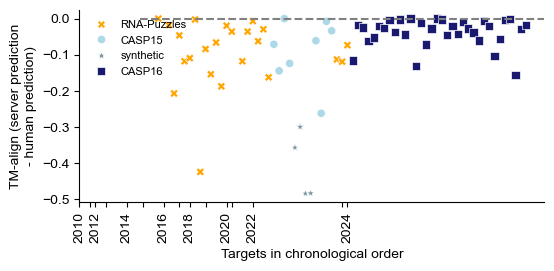

In [48]:
plt.figure(figsize=(6,2.5))

template_info['timestamp'] = pd.to_datetime(template_info['Competition Deadline']) 
template_info = template_info.sort_values(by='timestamp')
template_info['index'] = range(len(template_info))
g = sns.scatterplot(data=template_info,x='index',y='server_human_tm-align_diff',
               hue='Competition',style='Competition',
               markers=markers, palette=colors)
x0,x1 = g.get_xlim()
plt.hlines(0,x0,x1,linestyle='--', color='gray')
plt.xlim(x0,x1)
years = template_info['timestamp'].dt.year.unique()
year_indices = template_info.groupby(template_info['timestamp'].dt.year)['index'].first().values


# Set custom x-axis ticks and labels
t=plt.xticks([x-1 for x in year_indices], [x if int(x)%2==0 else '' for x in years],
          rotation=90,ha='center')

handles, labels = plt.gca().get_legend_handles_labels()
legend = plt.legend(handles, labels, loc='upper left', frameon=False, fontsize=8) 
sns.despine(right=True, top=True)

plt.xlabel('Targets in chronological order')
plt.ylabel('TM-align (server prediction\n- human prediction)')
plt.savefig(f"figure_subpanels/historical_tm_align_server_diff_timeline.png",dpi=400, bbox_inches='tight', transparent=True)
plt.savefig(f"figure_subpanels/historical_tm_align_server_diff_timeline.svg",dpi=400, bbox_inches='tight', transparent=True)
plt.show()

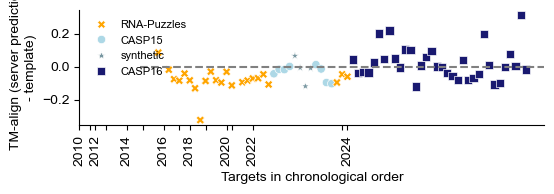

In [49]:
plt.figure(figsize=(6,1.5))

template_info['timestamp'] = pd.to_datetime(template_info['Competition Deadline']) 
template_info = template_info.sort_values(by='timestamp')
template_info['index'] = range(len(template_info))
g = sns.scatterplot(data=template_info,x='index',y='server_best_tm-align_diff',
               hue='Competition',style='Competition',
               markers=markers, palette=colors)
x0,x1 = g.get_xlim()
plt.hlines(0,x0,x1,linestyle='--', color='gray')
plt.xlim(x0,x1)
years = template_info['timestamp'].dt.year.unique()
year_indices = template_info.groupby(template_info['timestamp'].dt.year)['index'].first().values


# Set custom x-axis ticks and labels
t=plt.xticks([x-1 for x in year_indices], [x if int(x)%2==0 else '' for x in years],
          rotation=90,ha='center')

handles, labels = plt.gca().get_legend_handles_labels()
legend = plt.legend(handles, labels, loc='upper left', frameon=False, fontsize=8) 
sns.despine(right=True, top=True)

plt.xlabel('Targets in chronological order')
plt.ylabel('TM-align (server prediction\n- template)')
plt.show()

In [50]:
to_fit = template_info[template_info['server_best_tm-align_diff']==template_info['server_best_tm-align_diff']]
to_fit = to_fit[~to_fit.Target.isin( synthetics)]

to_fit2 = template_info.copy()
to_fit2 = to_fit2[~to_fit2.Target.isin( synthetics)]

In [51]:
to_fit['tm-align_diff'].max()

0.34051

In [52]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

X = sm.add_constant(to_fit['timestamp_numeric']) # Add a constant term (intercept)
y = to_fit['server_best_tm-align_diff']

# 2.  Fit the model (using Ordinary Least Squares)
model = sm.OLS(y, X).fit()

# 3.  Get the results
print(model.summary())

# 4.  Get the slope and intercept
slope = model.params['timestamp_numeric'] # or model.params[1]
intercept = model.params['const'] # or model.params[0]
print(f"Slope: {slope:.3f}")
print(f"Intercept: {intercept:.3f}")

# 5.  Optionally, get the p-value for the slope (to see if the trend is significant)
p_value = model.pvalues['timestamp_numeric'] # or model.pvalues[1]
print(f"P-value for time: {p_value:.3f}")

                                OLS Regression Results                               
Dep. Variable:     server_best_tm-align_diff   R-squared:                       0.139
Model:                                   OLS   Adj. R-squared:                  0.125
Method:                        Least Squares   F-statistic:                     10.15
Date:                       Fri, 26 Sep 2025   Prob (F-statistic):            0.00224
Time:                               14:09:14   Log-Likelihood:                 66.100
No. Observations:                         65   AIC:                            -128.2
Df Residuals:                             63   BIC:                            -123.9
Df Model:                                  1                                         
Covariance Type:                   nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------

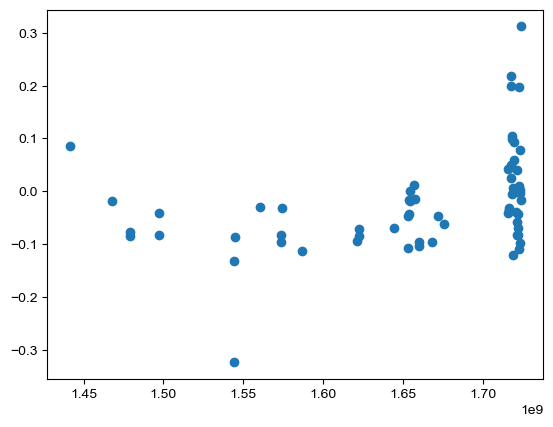

In [53]:
plt.scatter(to_fit['timestamp_numeric'],to_fit['server_best_tm-align_diff'])
plt.show()

In [54]:
# prior casp 16
# vs not
# server
# human
template_info['cat'] = template_info.Competition == 'CASP16'
to_plot = template_info[template_info.server_best==template_info.server_best]
to_plot = to_plot[~to_plot.Target.isin( synthetics)]

print(len(template_info),len(to_plot))
to_plot.head()

85 65


,Competition Deadline,Competition,Target,Target Description,Best Prediction,Best Prediction TM align,Best Template,Best Template Description,Best Template TM align,tm-align_ratio,tm-align_diff,timestamp,index,server_best,server_best_tm-align_ratio,server_best_tm-align_diff,server_human_tm-align_diff,timestamp_numeric,cat
14,04-Sep-2015,RNA-Puzzles,PZ15,Hammerhead Ribozyme. Predict as 2 chains,PZ15_Adamiak_3,0.59364,2QUW,Hammerhead Ribozyme G12A mutant after cleavage,0.50848,1.167480,0.08516,2015-09-04,14,0.59364,1.167480,0.08516,0.00000,1441324800,False
16,05-Jul-2016,RNA-Puzzles,PZ17,Pistol ribozyme,PZ17_Das_8,0.34714,4V6I,Localization of the small subunit ribosomal pr...,0.34775,0.998246,-0.00061,2016-07-05,16,0.32914,0.946485,-0.01861,-0.01800,1467676800,False
17,10-Nov-2016,RNA-Puzzles,PZ18,Zika virus,PZ18_DasORIGINAL_3,0.58249,4PQV,Crystal structure of an Xrn1-resistant RNA fro...,0.45140,1.290408,0.13109,2016-11-10,17,0.37535,0.831524,-0.07605,-0.20714,1478736000,False
18,10-Nov-2016,RNA-Puzzles,PZ19,One Twister Sister robozyme,PZ19_Chen_1,0.31653,4V4P,Crystal structure of 70S ribosome with thrS op...,0.35533,0.890806,-0.03880,2016-11-10,18,0.27017,0.760335,-0.08516,-0.04636,1478736000,False
19,14-Jun-2017,RNA-Puzzles,PZ20,Another Twister Sister ribozyme,PZ20_Das_2,0.32067,4V5E,Insights into translational termination from t...,0.25313,1.266819,0.06754,2017-06-14,19,0.21122,0.834433,-0.04191,-0.10945,1497398400,False


In [55]:
print(to_plot.groupby('cat')['server_best_tm-align_diff'].mean())
print(to_plot.groupby('cat')['server_best_tm-align_diff'].sem())
print(to_plot.groupby('cat')['tm-align_diff'].mean())
print(to_plot.groupby('cat')['tm-align_diff'].sem())


print(to_fit.groupby('cat')['server_best_tm-align_diff'].mean())
print(to_fit.groupby('cat')['server_best_tm-align_diff'].sem())
print(to_fit.groupby('cat')['tm-align_diff'].mean())
print(to_fit.groupby('cat')['tm-align_diff'].sem())

print(to_fit2.groupby('cat')['server_best_tm-align_diff'].mean())
print(to_fit2.groupby('cat')['server_best_tm-align_diff'].sem())
print(to_fit2.groupby('cat')['tm-align_diff'].mean())
print(to_fit2.groupby('cat')['tm-align_diff'].sem())


cat
False   -0.066835
True     0.021981
Name: server_best_tm-align_diff, dtype: float64
cat
False    0.011774
True     0.016923
Name: server_best_tm-align_diff, dtype: float64
cat
False    0.026651
True     0.059951
Name: tm-align_diff, dtype: float64
cat
False    0.014484
True     0.015966
Name: tm-align_diff, dtype: float64


KeyError: 'cat'

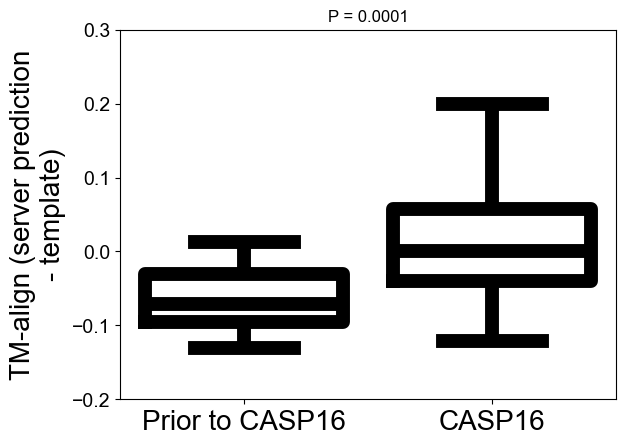

In [56]:
sns.boxplot(to_plot,y='server_best_tm-align_diff',x='cat',
            showfliers=False,#hue='cat',
           linewidth=10,fill=False,color='black')

#plt.title('Server - template TM-align\nprior to CASP16 compared to CASP16\nP = 0.0001 two-sided T')
plt.xlabel('', fontsize=12)
plt.ylabel('TM-align (server prediction\n- template)', fontsize=20)
plt.xticks(ticks=[0, 1], labels=['Prior to CASP16', 'CASP16'], fontsize=20)  # x-axis labels
plt.yticks(fontsize=14)  # y-axis label size
plt.title('P = 0.0001')
plt.ylim(-0.2,0.3)
plt.show()

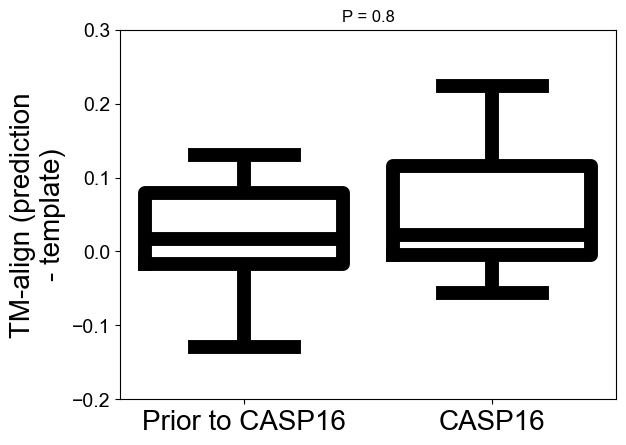

In [57]:
sns.boxplot(to_plot,y='tm-align_diff',x='cat',
            showfliers=False,#hue='cat',
           linewidth=10,fill=False,color='black')
#plt.title('Server - template TM-align\nprior to CASP16 compared to CASP16\nP = 0.0001 two-sided T')
plt.xlabel('', fontsize=12)
plt.ylabel('TM-align (prediction\n- template)', fontsize=20)
plt.xticks(ticks=[0, 1], labels=['Prior to CASP16', 'CASP16'], fontsize=20)  # x-axis labels
plt.yticks(fontsize=14)  # y-axis label size
plt.title('P = 0.8')
plt.ylim(-0.2,0.3)
plt.show()

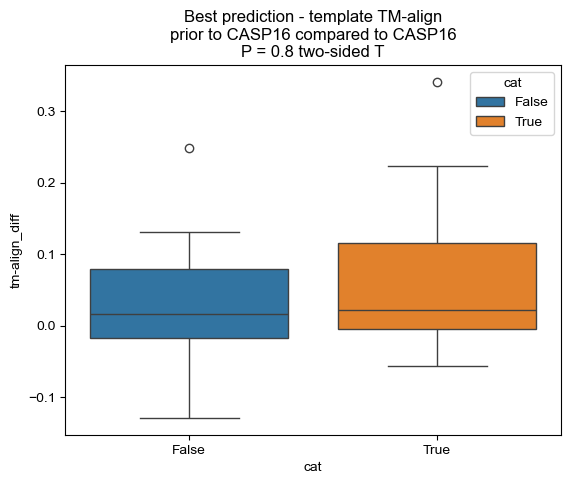

In [58]:
sns.boxplot(to_plot,y='tm-align_diff',x='cat',hue='cat')
plt.title('Best prediction - template TM-align\nprior to CASP16 compared to CASP16\nP = 0.8 two-sided T')
plt.show()

In [59]:
from scipy import stats
prior = to_plot.loc[~to_plot.cat,'tm-align_diff']
current = to_plot.loc[to_plot.cat,'tm-align_diff']
statistic, p_value = stats.levene(prior, current)
print(p_value>0.05,statistic,p_value)
t_statistic, p_value = stats.ttest_ind(prior, current, equal_var=True) 
# Assuming equal variance; use equal_var=False if variances are unequal
print(t_statistic, p_value)
t_statistic, p_value = stats.ttest_ind(prior, current, equal_var=False) 
print(t_statistic, p_value)

prior = to_plot.loc[~to_plot.cat,'server_best_tm-align_diff']
current = to_plot.loc[to_plot.cat,'server_best_tm-align_diff']
statistic, p_value = stats.levene(prior, current)
print(p_value>0.05,statistic,p_value) # then can use equal_var
t_statistic, p_value = stats.ttest_ind(prior, current, equal_var=True) 
# Assuming equal variance; use equal_var=False if variances are unequal
print(t_statistic, p_value)
t_statistic, p_value = stats.ttest_ind(prior, current, equal_var=False) 
print(t_statistic, p_value)

True 0.24800669823525445 0.6202161547593288
-1.5344502403501288 0.12992599199065166
-1.544741447648603 0.1274298329969576
True 3.5275488990640977 0.06498649308431585
-4.230593921979831 7.696409893704499e-05
-4.308155338281401 6.469956988956727e-05


In [60]:
prior = to_fit2.loc[~to_fit2.cat,'tm-align_diff']
current = to_fit2.loc[to_fit2.cat,'tm-align_diff']
statistic, p_value = stats.levene(prior, current)
print(p_value>0.05,statistic,p_value)
t_statistic, p_value = stats.ttest_ind(prior, current, equal_var=True) 
# Assuming equal variance; use equal_var=False if variances are unequal
print(t_statistic, p_value)
t_statistic, p_value = stats.ttest_ind(prior, current, equal_var=False) 
print(t_statistic, p_value)


AttributeError: 'DataFrame' object has no attribute 'cat'

In [61]:
template_info.Competition.unique()

array(['RNA-Puzzles', 'CASP15', 'synthetic', 'CASP16'], dtype=object)

In [62]:
c_rna_puzzle = template_info.Competition == 'RNA-Puzzles'
c_casp15 = (template_info.Competition == 'CASP15') | (template_info.Competition == 'synthetic')
c_prior_casp16 = c_rna_puzzle | c_casp15
c_casp16 = template_info.Competition == 'CASP16'
c_synthetic = template_info.Target.isin(synthetics)
c_server_not_participates = template_info['server_best_tm-align_diff']==template_info['server_best_tm-align_diff']

a = template_info[c_prior_casp16& c_server_not_participates]['tm-align_diff']
b = template_info[c_casp16& c_server_not_participates]['tm-align_diff']
print(a.describe())
print(b.describe())
t_statistic, p_value = stats.ttest_ind(a, b, equal_var=True) 
# Assuming equal variance; use equal_var=False if variances are unequal
print(t_statistic, p_value)


a = template_info[c_prior_casp16 & c_server_not_participates]['server_best_tm-align_diff']
b = template_info[c_casp16 & c_server_not_participates]['server_best_tm-align_diff']
print(a.sem())
print(b.describe())
t_statistic, p_value = stats.ttest_ind(a, b, equal_var=True) 
# Assuming equal variance; use equal_var=False if variances are unequal
print(t_statistic, p_value)


count    35.000000
mean      0.067959
std       0.141012
min      -0.128660
25%      -0.016660
50%       0.027860
75%       0.112135
max       0.473270
Name: tm-align_diff, dtype: float64
count    34.000000
mean      0.059951
std       0.093095
min      -0.055740
25%      -0.004502
50%       0.022585
75%       0.115665
max       0.340510
Name: tm-align_diff, dtype: float64
0.2775262948323838 0.7822305625788153
0.011404248183420578
count    34.000000
mean      0.021981
std       0.098674
min      -0.120860
25%      -0.039848
50%       0.001210
75%       0.057487
max       0.312290
Name: server_best_tm-align_diff, dtype: float64
-4.099499007322738 0.00011421242122514268


In [63]:
print(len(template_info[c_prior_casp16 & c_server_not_participates & ~c_synthetic]))
print(len(template_info[c_casp16 & c_server_not_participates & ~c_synthetic]))

31
34


In [64]:
a = template_info[c_rna_puzzle ]['tm-align_diff']
b = template_info[c_rna_puzzle & c_server_not_participates]['server_best_tm-align_diff']

print(a.sem())
print(a.describe())
print(b.sem())
print(b.describe())

0.011940156693259093
count    39.000000
mean      0.013492
std       0.074566
min      -0.144210
25%      -0.036090
50%      -0.000610
75%       0.070070
max       0.161380
Name: tm-align_diff, dtype: float64
0.014385541859455127
count    23.000000
mean     -0.077999
std       0.068991
min      -0.323570
25%      -0.095135
50%      -0.082560
75%      -0.046585
max       0.085160
Name: server_best_tm-align_diff, dtype: float64
